# Scaled Dot Product Attention

This notebook explores implementations of the Scaled Dot Product Attention mechanism, starting from high-level frameworks like TensorFlow and PyTorch, and moving into custom high-performance kernels using **Triton**.

## 1. High-Level Implementation (TensorFlow)

We begin with a simple demonstration using TensorFlow to understand the basic mechanism of Query (Q), Key (K), and Value (V) matrices.

Embedded Tokens:
tf.Tensor(
[[0.1 0.2 0.3]
 [0.4 0.5 0.6]
 [0.7 0.8 0.9]
 [0.1 0.2 0.3]
 [0.1 0.2 0.3]
 [0.4 0.5 0.6]
 [0.7 0.8 0.9]], shape=(7, 3), dtype=float32)

Attention Weights:
[[0.13  0.144 0.16  0.13  0.13  0.144 0.16 ]
 [0.112 0.145 0.188 0.112 0.112 0.145 0.188]
 [0.094 0.143 0.216 0.094 0.094 0.143 0.216]
 [0.13  0.144 0.16  0.13  0.13  0.144 0.16 ]
 [0.13  0.144 0.16  0.13  0.13  0.144 0.16 ]
 [0.112 0.145 0.188 0.112 0.112 0.145 0.188]
 [0.094 0.143 0.216 0.094 0.094 0.143 0.216]]

Output:
[[0.379 0.479 0.579]
 [0.412 0.512 0.612]
 [0.445 0.545 0.645]
 [0.379 0.479 0.579]
 [0.379 0.479 0.579]
 [0.412 0.512 0.612]
 [0.445 0.545 0.645]]


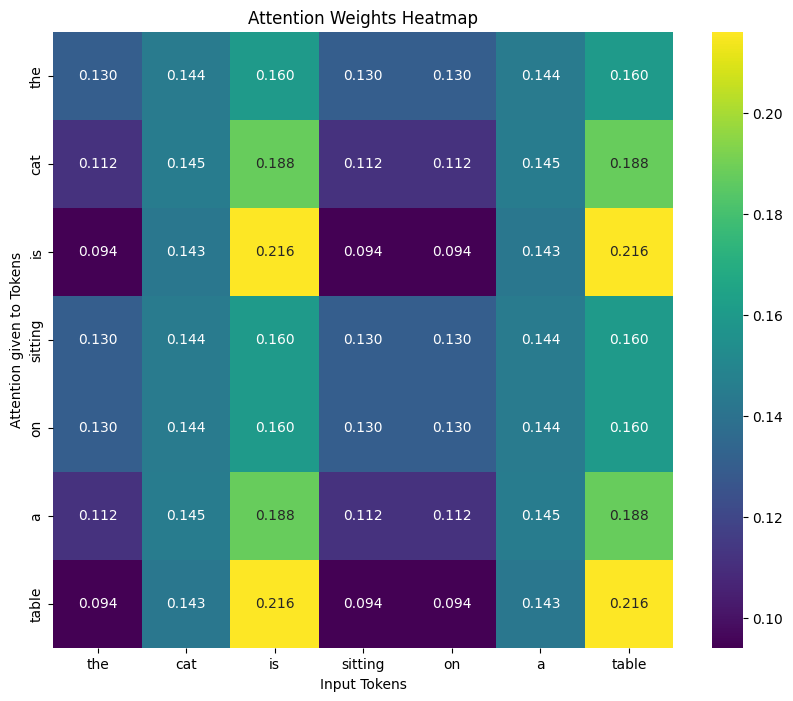

In [ ]:
# Scaled Dot Product Attention (TensorFlow)

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

embeddings = {
    "the" : np.array([0.1, 0.2, 0.3]),
    "cat" : np.array([0.4, 0.5, 0.6]),
    "is" : np.array([0.7, 0.8, 0.9]),
    "sitting" : np.array([0.1, 0.2, 0.3]),
    "on" : np.array([0.1, 0.2, 0.3]),
    "a" : np.array([0.4, 0.5, 0.6]),
    "table" : np.array([0.7, 0.8, 0.9])
}

sentence = ["the",  "cat",  "is",  "sitting", "on", "a" ,"table"]

embedded_tokens = tf.constant([embeddings[token] for token in sentence], dtype=tf.float32)
print("Embedded Tokens:")
print(embedded_tokens)

def scaled_dot_product_attention (q,k,v, mask = None):
  matmul_qk = tf.matmul(q, k, transpose_b = True)
  dk = tf.cast(tf.shape(k)[-1], tf.float32)
  scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

  if mask is not None:
    scaled_attention_logits += (mask * -1e9)
  attention_weights = tf.nn.softmax(scaled_attention_logits, axis = -1)
  output = tf.matmul(attention_weights, v)
  return output, attention_weights

# Define Q, K, V for self-attention
Q = embedded_tokens
K = embedded_tokens
V = embedded_tokens

# Apply self-attention
output, attention_weights = scaled_dot_product_attention(Q, K, V)

np.set_printoptions(precision=3, suppress=True)

print("\nAttention Weights:")
print(attention_weights.numpy())

print("\nOutput:")
print(output.numpy())

# Visualize attention weights
tokens = sentence
plt.figure(figsize=(10, 8))
sns.heatmap(attention_weights.numpy(), xticklabels=tokens, yticklabels=tokens, cmap='viridis', annot=True, fmt=".3f")
plt.xlabel('Input Tokens')
plt.ylabel('Attention given to Tokens')
plt.title('Attention Weights Heatmap')
plt.show()

## 2. Standard PyTorch Implementation

Next, we implement the same mechanism in PyTorch and compare it against the built-in `F.scaled_dot_product_attention` for validation.

In [ ]:
import torch
import torch.nn.functional as F
import math

token_ids = [0, 5, 4, 9, 7, 2, 8, 10, 1, 6, 3]
token_ids = torch.tensor(token_ids, dtype=torch.int64)

torch.manual_seed(42)

vocab_size = 2000
d_model = 32

embedding = torch.nn.Embedding(vocab_size, d_model)
X = embedding(token_ids)

W_q = torch.randn(d_model, d_model) * 0.1
W_k = torch.randn(d_model, d_model) * 0.1
W_v = torch.randn(d_model, d_model) * 0.1


def attention(X, W_q, W_k, W_v):
    Q = X.matmul(W_q)
    K = X.matmul(W_k)
    V = X.matmul(W_v)

    assert Q.shape == K.shape == V.shape

    compat = Q.matmul(K.T)
    d_k = Q.shape[-1]
    scaled_compat = compat / math.sqrt(d_k)

    weights = torch.softmax(scaled_compat, dim=-1)

    row_sums = weights.sum(dim=-1)
    assert torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-5)

    output = weights.matmul(V)

    return output, weights


output, weights = attention(X, W_q, W_k, W_v)

print("Attention weights:\n", weights)
print("\nRow sums:\n", weights.sum(dim=-1))
print("\nOutput:\n", output)

Q = X.matmul(W_q)
K = X.matmul(W_k)
V = X.matmul(W_v)

ref_output = F.scaled_dot_product_attention(Q, K, V)

match = torch.allclose(output, ref_output, atol=1e-4)
print("\nMatches PyTorch reference:", match)
if not match:
    print("Max abs diff:", (output - ref_output).abs().max().item())

Attention weights:
 tensor([[0.1003, 0.0686, 0.1092, 0.1059, 0.0759, 0.1066, 0.0557, 0.0868, 0.1158,
         0.1000, 0.0751],
        [0.0734, 0.0839, 0.1149, 0.1400, 0.0655, 0.0498, 0.1283, 0.0785, 0.0863,
         0.1333, 0.0460],
        [0.0773, 0.0650, 0.1368, 0.0855, 0.0961, 0.1521, 0.0434, 0.1078, 0.0692,
         0.0928, 0.0740],
        [0.1331, 0.0807, 0.0748, 0.0901, 0.0665, 0.1327, 0.0948, 0.1226, 0.0632,
         0.0766, 0.0649],
        [0.0836, 0.0768, 0.0728, 0.0827, 0.1012, 0.1386, 0.0651, 0.0934, 0.0934,
         0.1229, 0.0696],
        [0.0821, 0.0988, 0.0896, 0.0885, 0.1478, 0.0552, 0.0548, 0.0676, 0.1261,
         0.0622, 0.1273],
        [0.1003, 0.0762, 0.1288, 0.0894, 0.1001, 0.0743, 0.0670, 0.0574, 0.0854,
         0.1405, 0.0807],
        [0.0945, 0.0883, 0.1011, 0.0851, 0.1140, 0.0925, 0.0785, 0.1134, 0.0817,
         0.0618, 0.0890],
        [0.0530, 0.0996, 0.1237, 0.0915, 0.0863, 0.0560, 0.1067, 0.0799, 0.0997,
         0.1051, 0.0985],
        [0.0916, 

## 3. Introduction to Triton Kernels

To optimize performance, we can write custom GPU kernels using Triton. We'll start with a basic vector addition kernel to understand Triton's programming model (PIDs, offsets, and masking).

In [1]:
!pip install triton torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.0/248.0 MB 6.8 MB/s eta 0:00:00


In [4]:
import torch
import triton
import triton.language as tl

@triton.jit

def add_kernel(x_ptr,y_ptr, out_ptr, n_elements, BLOCK_SIZE: tl.constexpr):
  pid = tl.program_id(axis = 0)
  block_start = pid * BLOCK_SIZE
  offsets = block_start + tl.arange(0, BLOCK_SIZE)
  mask = offsets < n_elements

  x = tl.load(x_ptr + offsets , mask=mask)
  y = tl.load(y_ptr + offsets , mask=mask)

  out = x+y
  tl.store(out_ptr + offsets, out, mask=mask)


def triton_add(x: torch.Tensor, y:torch.Tensor):
  output= torch.empty_like(x)
  n_elements= x.numel()
  BLOCK_SIZE= 1024

  grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)
  add_kernel[grid](x, y, output, n_elements, BLOCK_SIZE=BLOCK_SIZE)
  return output


# 1. Enforce CUDA check
device = 'cuda'

x = torch.rand(10000, device=device)
y = torch.rand(10000, device=device)

triton_res = triton_add(x, y)
torch_res = x + y

print("Vector Add Matches PyTorch?", torch.allclose(triton_res, torch_res))



Vector Add Matches PyTorch? True


## 4. Fused ReLU & Dropout Kernel

This kernel demonstrates how to fuse multiple operations (ReLU activation and Dropout) into a single Triton pass. We include a statistical test to verify the correctness of the stochastic dropout operation.

In [15]:
import triton
import torch
import triton.language as tl

@triton.jit

def relu_dropout_kernel(x_ptr, out_ptr, n_elements, p, seed, BLOCK_SIZE: tl.constexpr):
  pid = tl.program_id(axis = 0)
  offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
  mask = offsets < n_elements

  x = tl.load(x_ptr + offsets, mask = mask)
  x = tl.maximum(x, 0.0)
  randoms = tl.rand(seed, offsets)
  dropout_mask = randoms > p


  out = tl.where(dropout_mask, x / (1 - p), 0.0)

  tl.store(out_ptr + offsets, out, mask = mask)

def triton_relu_dropout(x : torch.Tensor, p:float, seed : int = 42):
  output = torch.empty_like(x)
  n_elements = x.numel()
  BLOCK_SIZE = 1024
  grid = lambda meta:(triton.cdiv(n_elements, meta['BLOCK_SIZE']),)

  relu_dropout_kernel[grid](x, output, n_elements, p, seed, BLOCK_SIZE=BLOCK_SIZE)
  return output

x = torch.randn(5000, device='cuda')
out = triton_relu_dropout(x, p=0.2)
print("Fused Activation Output:\n", out[:5])

Fused Activation Output:
 tensor([2.5289, 0.0000, 0.0000, 0.0000, 0.1839], device='cuda:0')


### Statistical Correctness Test for Dropout

A stochastic operation like dropout can't be checked by eyeballing a handful of output values — the only real test is statistical. I check two things: that the empirical dropout rate lands close to the target probability `p`, and that the elements that survive are scaled by `1 / (1 - p)`.

In [14]:
import numpy as np

def run_relu_dropout_test(size, p, atol=1e-2, rtol=1e-2):
    print(f"\n--- Testing ReLU Dropout with size={size}, p={p} ---")

    # Generate a large tensor to ensure statistical significance
    x = torch.randn(size, device='cuda')
    # Ensure some values are negative and some positive to test ReLU
    x_initial = x.clone()

    # Run Triton ReLU Dropout
    out = triton_relu_dropout(x, p=p, seed=42)

    # 1. Check ReLU behavior (already covered by scaling check if p=0)

    # 2. Check dropout rate more accurately
    # Count elements that were originally positive but became zero in the output
    num_positive_initial = (x_initial > 0).sum().item()
    num_positive_and_dropped = ((x_initial > 0) & (out == 0)).sum().item()

    if num_positive_initial > 0:
        empirical_dropout_rate_from_positive = num_positive_and_dropped / num_positive_initial
    else:
        empirical_dropout_rate_from_positive = 0.0 # If no positive elements, no dropout can occur on them

    # Expected number of zeros among initially positive elements should be close to p
    dropout_rate_match = (empirical_dropout_rate_from_positive >= (p - atol)) and (empirical_dropout_rate_from_positive <= (p + atol))
    print(f"Empirical dropout rate (from positive): {empirical_dropout_rate_from_positive:.4f} (Expected: {p:.2f} +/- {atol:.2f})")
    print(f"Dropout rate within expected range: {dropout_rate_match}")

    # 3. Check scaling of non-zero elements
    # We need to filter for elements that were originally positive AND kept by dropout
    # For this, 'kept_mask' was `(out != 0)`
    kept_mask = (out != 0)

    # The reference for scaling should be based on the original positive values
    ref_out_relu = torch.max(x_initial, torch.tensor(0.0, device='cuda'))

    if p < 1.0:
        # Only consider elements that were originally positive and were kept
        # This ensures we're not checking scaling of values that were already zero from ReLU
        actual_kept_values = out[kept_mask]
        expected_scaled_value_for_kept = ref_out_relu[kept_mask] / (1 - p)

        scaling_match = torch.allclose(actual_kept_values, expected_scaled_value_for_kept, atol=atol, rtol=rtol)
        print(f"Scaling of kept elements matches: {scaling_match}")
        if not scaling_match:
            max_diff = (actual_kept_values - expected_scaled_value_for_kept).abs().max().item()
            print(f"Max abs diff in scaling: {max_diff}")
    else:
        # If p=1.0, all elements should be zero
        scaling_match = (out == 0).all()
        print(f"Scaling of kept elements matches (all zeros for p=1.0): {scaling_match}")

    return dropout_rate_match and scaling_match


# Run statistical tests
_ = run_relu_dropout_test(size=100000, p=0.1)
_ = run_relu_dropout_test(size=100000, p=0.5)
_ = run_relu_dropout_test(size=100000, p=0.9)
_ = run_relu_dropout_test(size=100000, p=0.0) # No dropout, only ReLU, scaling by 1.0
_ = run_relu_dropout_test(size=100000, p=1.0) # All elements should be zero


--- Testing ReLU Dropout with size=100000, p=0.1 ---
Empirical dropout rate (from positive): 0.1007 (Expected: 0.10 +/- 0.01)
Dropout rate within expected range: True
Scaling of kept elements matches: True

--- Testing ReLU Dropout with size=100000, p=0.5 ---
Empirical dropout rate (from positive): 0.4993 (Expected: 0.50 +/- 0.01)
Dropout rate within expected range: True
Scaling of kept elements matches: True

--- Testing ReLU Dropout with size=100000, p=0.9 ---
Empirical dropout rate (from positive): 0.8999 (Expected: 0.90 +/- 0.01)
Dropout rate within expected range: True
Scaling of kept elements matches: True

--- Testing ReLU Dropout with size=100000, p=0.0 ---
Empirical dropout rate (from positive): 0.0000 (Expected: 0.00 +/- 0.01)
Dropout rate within expected range: True
Scaling of kept elements matches: True

--- Testing ReLU Dropout with size=100000, p=1.0 ---
Empirical dropout rate (from positive): 1.0000 (Expected: 1.00 +/- 0.01)
Dropout rate within expected range: True
Scal

## 5. Optimized Softmax Kernel

Softmax requires calculating exponentials and sums across a dimension. We've implemented a version that dynamically adjusts its `BLOCK_SIZE` to handle varying input widths.

In [9]:
import triton, torch
import triton.language as tl

@triton.jit

def softmax(output_ptr, input_ptr, input_row_stride, output_row_stride, n_cols, BLOCK_SIZE: tl.constexpr):
  row_idx = tl.program_id(0)
  row_start_ptr = input_ptr + row_idx * input_row_stride
  col_offsets = tl.arange(0, BLOCK_SIZE)
  input_ptrs = row_start_ptr + col_offsets

  mask = col_offsets < n_cols
  row = tl.load(input_ptrs, mask = mask, other=float("-inf"))
  row_max = tl.max(row, axis = 0)
  numerator = tl.exp(row - row_max)
  denominator = tl.sum(numerator, axis = 0)
  softmax_output = numerator/denominator

  output_row_start_ptr = output_ptr + row_idx * output_row_stride
  output_ptrs = output_row_start_ptr + col_offsets
  tl.store(output_ptrs, softmax_output, mask=mask)

def triton_softmax(x: torch.Tensor):
  n_rows, n_cols = x.shape
  BLOCK_SIZE = 1024
  output = torch.empty_like(x)
  grid = (n_rows,)

  softmax[grid](
      output, x,
      x.stride(0), output.stride(0),
      n_cols, BLOCK_SIZE=BLOCK_SIZE
  )
  return output

# Test it!
x = torch.randn(4, 5, device='cuda')
triton_res = triton_softmax(x)
torch_res = torch.softmax(x, dim=-1)

print("Softmax Matches PyTorch?", torch.allclose(triton_res, torch_res, atol=1e-5))

Softmax Matches PyTorch? True


I hardcoded `BLOCK_SIZE` to 1024 above, which works by luck when `n_cols` is small: `col_offsets` only ever spans `BLOCK_SIZE` elements, so once `n_cols` exceeds that, the kernel silently only processes the first 1024 columns and produces the wrong output. Here's that failure reproduced at `n_cols=2000`.

**Before**

In [10]:
# Same hardcoded BLOCK_SIZE as above
def triton_softmax_buggy(x: torch.Tensor):
  n_rows, n_cols = x.shape
  BLOCK_SIZE = 1024 # Hardcoded BLOCK_SIZE
  output = torch.empty_like(x)
  grid = (n_rows,)

  softmax[grid](
      output, x,
      x.stride(0), output.stride(0),
      n_cols, BLOCK_SIZE=BLOCK_SIZE
  )
  return output

# Test case to demonstrate the bug (n_cols > 1024)
print("\n--- Testing with n_cols > 1024 (Buggy `triton_softmax`) ---")
x_buggy = torch.randn(2, 2000, device='cuda') # n_cols = 2000 > 1024

try:
    triton_res_buggy = triton_softmax_buggy(x_buggy)
    torch_res_buggy = torch.softmax(x_buggy, dim=-1)
    match_buggy = torch.allclose(triton_res_buggy, torch_res_buggy, atol=1e-5)
    print(f"Buggy Softmax Matches PyTorch (n_cols=2000)? {match_buggy}")
    if not match_buggy:
        print(f"Max abs diff: {(triton_res_buggy - torch_res_buggy).abs().max().item()}")
except Exception as e:
    print(f"Error with buggy softmax: {e}")


--- Testing with n_cols > 1024 (Buggy `triton_softmax`) ---
Buggy Softmax Matches PyTorch (n_cols=2000)? False
Max abs diff: 0.009781374596059322


The fix is one line: size `BLOCK_SIZE` to cover every column instead of guessing a fixed number.

**After**

In [11]:
# Corrected `triton_softmax`
def triton_softmax(x: torch.Tensor):
  n_rows, n_cols = x.shape
  BLOCK_SIZE = triton.next_power_of_2(n_cols) # Dynamically set BLOCK_SIZE
  output = torch.empty_like(x)
  grid = (n_rows,)

  softmax[grid](
      output, x,
      x.stride(0), output.stride(0),
      n_cols, BLOCK_SIZE=BLOCK_SIZE
  )
  return output

# Test the corrected version with n_cols > 1024
print("\n--- Testing with n_cols > 1024 (Corrected `triton_softmax`) ---")
x_fixed = torch.randn(2, 2000, device='cuda')
triton_res_fixed = triton_softmax(x_fixed)
torch_res_fixed = torch.softmax(x_fixed, dim=-1)
match_fixed = torch.allclose(triton_res_fixed, torch_res_fixed, atol=1e-5)
print(f"Corrected Softmax Matches PyTorch (n_cols=2000)? {match_fixed}")
if not match_fixed:
    print(f"Max abs diff: {(triton_res_fixed - torch_res_fixed).abs().max().item()}")


--- Testing with n_cols > 1024 (Corrected `triton_softmax`) ---
Corrected Softmax Matches PyTorch (n_cols=2000)? True


## 6. Triton Self-Attention Kernel

Finally, we implement the full Scaled Dot Product Attention as a custom Triton kernel. This implementation utilizes `tl.dot` for hardware-accelerated matrix multiplication.

In [3]:
import torch
import triton
import triton.language as tl

@triton.jit
def attention_kernel(
    q_ptr, k_ptr, v_ptr, out_ptr,
    row_stride, col_stride,
    n_rows, n_cols,
    scale,
    BLOCK_Q: tl.constexpr,
    BLOCK_K: tl.constexpr,
    BLOCK_V: tl.constexpr,
):
    row_pid = tl.program_id(0)

    row_offsets = row_pid * BLOCK_Q + tl.arange(0, BLOCK_Q)
    col_offsets = tl.arange(0, BLOCK_K)
    d_offsets = tl.arange(0, BLOCK_V)

    row_mask = row_offsets < n_rows
    col_mask = col_offsets < n_cols

    q_offsets = tl.expand_dims(row_offsets, 1) * row_stride + tl.expand_dims(d_offsets, 0) * col_stride
    q = tl.load(q_ptr + q_offsets, mask=tl.expand_dims(row_mask, 1), other=0.0)


    k_offsets = tl.expand_dims(d_offsets, 1) * col_stride + tl.expand_dims(col_offsets, 0) * row_stride
    k = tl.load(k_ptr + k_offsets, mask=tl.expand_dims(col_mask, 0), other=0.0)

    qk = tl.dot(q, k) * scale
    qk = tl.where(tl.expand_dims(col_mask, 0), qk, float("-inf"))

    m = tl.max(qk, axis=1)
    p = tl.exp(qk - tl.expand_dims(m, 1))
    l = tl.sum(p, axis=1)
    weights = p / tl.expand_dims(l, 1)

    v_offsets = tl.expand_dims(col_offsets, 1) * row_stride + tl.expand_dims(d_offsets, 0) * col_stride
    v = tl.load(v_ptr + v_offsets, mask=tl.expand_dims(col_mask, 1), other=0.0)

    out = tl.dot(weights.to(v.dtype), v)

    out_offsets = tl.expand_dims(row_offsets, 1) * row_stride + tl.expand_dims(d_offsets, 0) * col_stride
    tl.store(out_ptr + out_offsets, out, mask=tl.expand_dims(row_mask, 1))


def triton_attention(q, k, v):
    n_rows, d_model = q.shape
    n_cols = k.shape[0]
    scale = 1.0 / (d_model ** 0.5)

    out = torch.empty_like(q)
    BLOCK_Q = 16
    BLOCK_K = triton.next_power_of_2(n_cols)
    BLOCK_V = d_model

    grid = (triton.cdiv(n_rows, BLOCK_Q),)
    attention_kernel[grid](
        q, k, v, out,
        q.stride(0), q.stride(1),
        n_rows, n_cols,
        scale,
        BLOCK_Q=BLOCK_Q, BLOCK_K=BLOCK_K, BLOCK_V=BLOCK_V,
    )
    return out



I ran this against a handful of other shapes during development too (matched square Q/K/V, a larger standard case) — all passed. Two representative cases below: mismatched Q/K sequence lengths, and a single-query edge case.

In [5]:
import torch.nn.functional as F

def run_attention_test(q_shape, k_shape, v_shape, atol=1e-5):
    print(f"\nTesting with Q: {q_shape}, K: {k_shape}, V: {v_shape}")
    try:
        # Generate random inputs on CUDA
        q = torch.randn(q_shape, device='cuda')
        k = torch.randn(k_shape, device='cuda')
        v = torch.randn(v_shape, device='cuda')

        # Triton attention
        triton_out = triton_attention(q, k, v)

        # PyTorch reference attention
        torch_out = F.scaled_dot_product_attention(q, k, v)

        # Compare results
        match = torch.allclose(triton_out, torch_out, atol=atol)
        print(f"Output matches PyTorch reference: {match}")
        if not match:
            max_diff = (triton_out - torch_out).abs().max().item()
            print(f"Max absolute difference: {max_diff}")
    except Exception as e:
        print(f"An error occurred during test: {e}")

# Two representative shapes (more were tested during development, see above)
run_attention_test(q_shape=(5, 32), k_shape=(15, 32), v_shape=(15, 32)) # Different sequence lengths
run_attention_test(q_shape=(1, 64), k_shape=(10, 64), v_shape=(10, 64))  # Single query


Testing with Q: (5, 32), K: (15, 32), V: (15, 32)
Output matches PyTorch reference: True

Testing with Q: (1, 64), K: (10, 64), V: (10, 64)
Output matches PyTorch reference: True


### Conclusion

Starting from vector addition, I built up to a fused ReLU+dropout kernel (with a statistical test, since a stochastic op can't be checked by eye), a fused softmax kernel (including one real correctness bug — a hardcoded `BLOCK_SIZE` that silently broke past 1024 columns — found and fixed), and a naive single-block attention kernel validated against `F.scaled_dot_product_attention` across several shapes.

The attention kernel here is naive in one specific way that matters: it loads all of K and V into SRAM at once, which is fine for the short sequences tested but doesn't scale to long ones. Real FlashAttention-style kernels process K and V in chunks, using an online (running max/sum) softmax so the full attention matrix never has to exist in memory at once. That's a harder algorithmic step I haven't implemented here — a real next wall, not a footnote.